# Student Module Preference Feedback Analysis

This notebook analyses student feedback from a Microsoft Forms survey where students selected their **top three Level 3 Computer Science modules**.

The aim is to understand **which modules are most popular and which are commonly chosen together**, so that the 9 modules can be grouped into **three separate buckets** in a way that minimises clashes and reflects student preferences.

## What this notebook does
- Identifies the **most popular modules overall**
- Finds **module combinations** in ascending order
- Examines which modules are often chosen together with popular modules
- Visualises module pairings using simple heatmaps

## Outputs
- Tables showing popular and less popular modules
- Conditional probabilities of choosing a module given a popular one
- Heatmaps of module pair selections
- Excel file with module combinations and their frequency
## Purpose

The results are intended to support **data-informed curriculum planning**, helping staff place modules into buckets in a way that works for the largest number of students.


## Data Loading and Cleaning

This section loads the survey data from an Excel file and performs basic data cleaning to ensure the analysis is reliable.

The following steps are applied:
- Load the dataset using pandas
- Rename columns to simpler, code-friendly names
- Remove irrelevant columns (timestamps, email, name, etc.)
- Convert year and programme values into consistent formats
- Remove invalid responses where the same module was selected more than once
- Remove responses containing an invalid module option
- Check for and remove any rows with missing values


In [1]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations


data_path = r'..\data\Level 3 module preference feedback(1-150).xlsx' # Data path

df = pd.read_excel(data_path)
# print(df.shape)

# Data cleaning : removing identical module choice, invalid module choice
# Data columns : dropped irrelevant columns : ID, times, email, name, last modified. Renamed columns to code friendly names (Year, Program)

df = df.rename(columns={"What year are you in?":"Year", "What is your program of study(Please select regular CS if your program is not listed)":"Program", "First module":"first_choice", "Second module":"second_choice", "Third module":"third_choice"})
df = df.drop(['Start time', 'Completion time', 'Email', 'Name', 'Last modified time'], axis=1)
# print(df.columns)

df['Year'] = df["Year"].replace({"Year 1":1, "Year 2":2, "Year 3":3})
df['Program'] = df["Program"].replace({'Computer Science':"CS", 'Computer Science (Artificial Intelligence)': "CS/AI", 'Computer Science (High-Performance Graphics and Games Engineering)':"CS/HPG" })


dup_rows = df[
    (df['first_choice'] == df['second_choice']) |
    (df['first_choice'] == df['third_choice']) |
    (df['second_choice'] == df['third_choice'])
]

to_drop= df[df.isin(["User adaptive intelligent systems"]).any(axis=1)]
# print(to_drop)
df=df.drop(to_drop.index)
# check for null values
null_mask = df.isnull().any(axis=1) #to check each row, defualt of axis=0, checks column vis
null_rows = df[null_mask]
df = df.drop(dup_rows.index)




## Module Popularity and Common Combinations

This section analyses overall module popularity and identifies common combinations of three modules chosen by students.

The following steps are performed:
- Extract the full list of available modules from student choices
- Count how often each module appears as a first, second, and third preference
- Compute both non-weighted and weighted popularity scores (Weighted : {first: 3 points}, {second: 2 points}, {third: 1 point})
- Identify the most popular modules overall
- Find combinations of three modules and their frequency -> export to popular_combinations.xlsx file


In [ ]:
all_modules = pd.unique(df[['first_choice', 'second_choice', 'third_choice']].values.ravel())
# print(all_modules)



popularity_table_count = pd.concat(
    [df['first_choice'].value_counts(), df['second_choice'].value_counts(), df['third_choice'].value_counts()],
    axis=1
)
popularity_table_count.columns = ['First', 'Second', 'Third']
popularity_table_count['Non Weighted'] = (popularity_table_count['First'] + popularity_table_count['Second'] + popularity_table_count['Third'])
popularity_table_count['Weighted'] = (popularity_table_count['First']*3 + popularity_table_count['Second']*2 + popularity_table_count['Third'])
# popularity_table_count['Total'] = popularity_table_count.sum(axis=1)
print("Popularity of each module : weighted and non weighted")
print(popularity_table_count.sort_values('Weighted', ascending=False))


module_choices_df = df.drop(['ID', 'Year', 'Program'], axis = 1)

list_combinations = module_choices_df.values.tolist()
sorted_combinations_list = [tuple(sorted(ls)) for ls in list_combinations]

triples_counts = Counter(sorted_combinations_list)


# 3. Convert to DataFrame
triplet_df = pd.DataFrame(
    triples_counts.items(),
    columns=["Triplet", "Count"]
).sort_values("Count", ascending=False)

triplet_df.to_excel("popular_combinations.xlsx", index=False)


                                  First  Second  Third  Non Weighted  Weighted
Artificial Intelligence              55      22     17            94       226
Computer Graphics                    24      19      7            50       117
Data Analytics                       14      27     16            57       112
High Performance Computing           12      20     13            45        89
Cryptography                         11      10     22            43        75
Innovation Thinking and Practice     12       9     18            39        72
Algorithms and Complexity             6       9     14            29        50
Secure Distributed Systems            5      12     11            28        50
Compilers                             7       9      8            24        47
Optimisation Models and Methods       1      10     21            32        44


Top 3 : AI, Comp Graphics, Data Analytics

Now we see if a student chooses AI (any prefernce), which pair of modules are they most likely to combine it with. 
A co-occurence frequence of pairs of modules, given AI is already choosen

## Conditional Module Analysis for Popular Modules

This section analyses module choices **conditional on a popular module being selected** (e.g. Artificial Intelligence, Data Analytics, High Performance Computing).

For each popular module:
- Student responses are filtered to only those who selected that module
- The remaining two module choices are extracted in preference order
- A weighted score is calculated to reflect how strongly each remaining module is preferred
- A co-occurrence matrix is constructed to show how often remaining modules are chosen together

The results help identify which modules are most likely (or least likely) to be combined with popular modules, supporting informed bucket placement decisions.


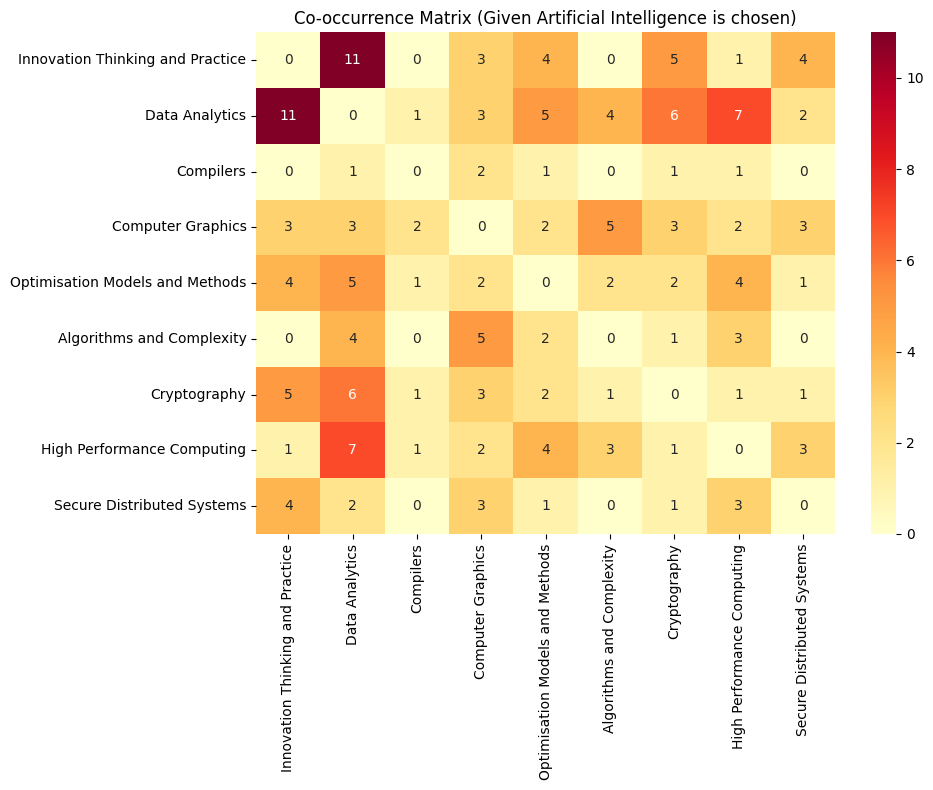

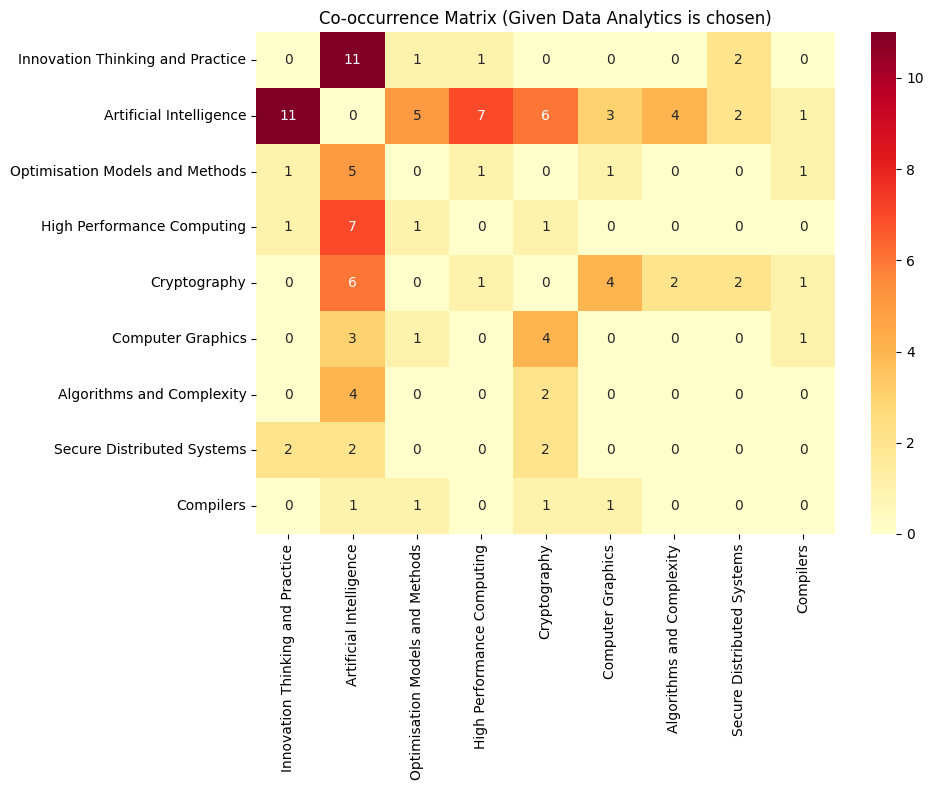

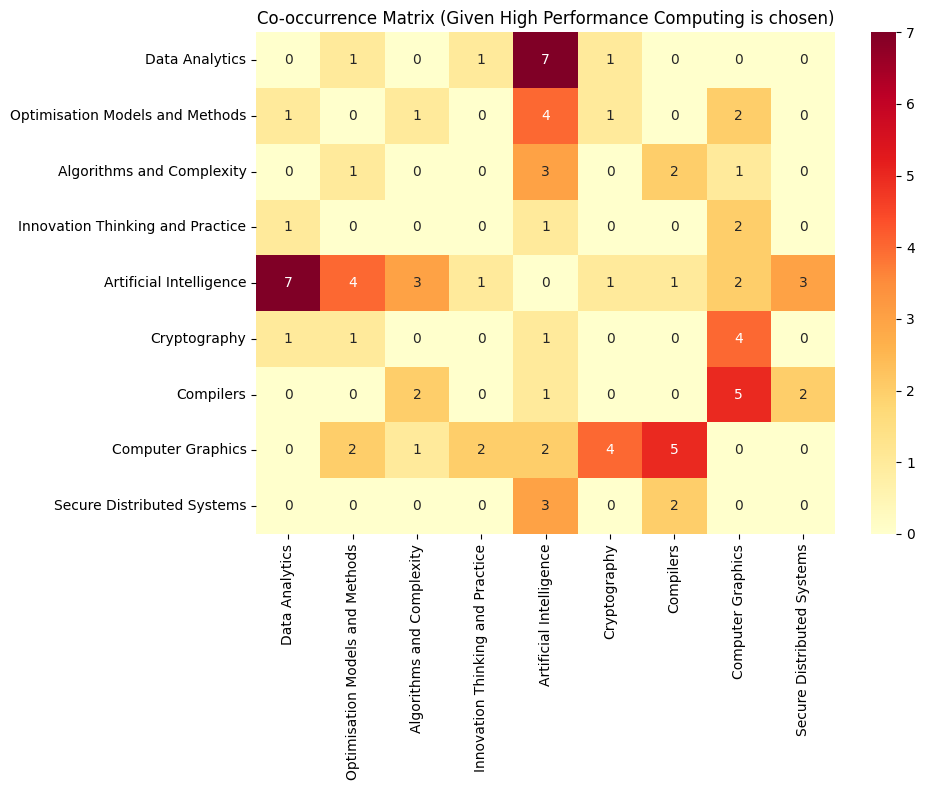

Probability given student has chosen AI/DATA or HPC
                                  AI_weight  DA_weight  HPC_weight
Innovation Thinking and Practice   0.181416   0.196429    0.044944
Compilers                          0.044248   0.044643    0.157303
Computer Graphics                  0.168142   0.142857    0.337079
Optimisation Models and Methods    0.123894   0.080357    0.101124
Cryptography                       0.128319   0.196429    0.089888
Algorithms and Complexity          0.088496   0.071429    0.112360
Secure Distributed Systems         0.079646   0.071429    0.067416


In [ ]:


combined_results = []

# Most popular modules
fixed = ["Artificial Intelligence", "Data Analytics", "High Performance Computing"]

# Function to extract pair of modules, in combinations where a fixed module is chosen i.e If a student has chosen AI | Data | HPC : extract the other two modules
def extract_pair(row, fixed_module):
    modules = [row["first_choice"], row["second_choice"], row["third_choice"]]
    remaining = [m for m in modules if m!= fixed_module]
    return pd.Series({"rem1": remaining[0], "rem2": remaining[1]})

# Looping through each fixed preference
for i in fixed:
    
    # Filter rows where the fixed module appears in any preference
    fixed_df = df[
        (df["first_choice"] == i) |
        (df["second_choice"] == i) |
        (df["third_choice"] == i)
    ]
    
    # Extract pairs of modules where one of the fixed is chosen
    pairs = fixed_df.apply(lambda row: extract_pair(row,i), axis=1)
    
    # Count how often each module occurs as first preference and second preference
    rem1_counts = pairs["rem1"].value_counts()
    rem2_counts = pairs["rem2"].value_counts()
    
    # Get weighted value of fixed module
    fixed_weighted = popularity_table_count.loc[i, "Weighted"]

    # Add count columns to df
    combined = pd.DataFrame({
    "rem1_count": rem1_counts,
    "rem2_count": rem2_counts
    }).fillna(0)
    
    # Compute a weighted score:
    # rem1 gets weight 2, rem2 gets weight 1
    # divide by the fixed module's total weight to standardise (conditional probability)
    combined["weighted_total"] = (combined["rem1_count"]*2 + combined["rem2_count"]*1)/fixed_weighted #divide by total of fixed to get standardized value
    
    # combined["weighted_total"] = (combined["rem1_count"] + combined["rem2_count"])/fixed_weighted #divide by total of fixed to get standardized value

    combined = combined.sort_values("weighted_total", ascending=False)
    combined_results.append(combined) #list to have results for all three fixed modules

    other_modules = pd.unique(pairs[['rem1', 'rem2']].values.ravel()) 


    # Create co-occurrence matrix of all other modules
    cooccur = pd.DataFrame(0, index=other_modules, columns=other_modules)
    
    # Count how many times each pair appears together
    for idx, row in pairs.iterrows():
        mod1, mod2 = row['rem1'], row['rem2']
        cooccur.loc[mod1, mod2] += 1
        cooccur.loc[mod2, mod1] += 1

   

    plt.figure(figsize=(10, 8))
    sns.heatmap(cooccur, annot=True, fmt='d', cmap='YlOrRd')
    plt.title(f'Co-occurrence Matrix (Given {i} is chosen)')
    plt.tight_layout()
    plt.show()
    
    # print(combined)


other_modules = [m for m in all_modules if m not in fixed]

comparison_df = pd.DataFrame(index=other_modules, columns=['AI_weight', 'DA_weight', 'HPC_weight'])
comparison_df['AI_chosen'] = combined_results[0]['weighted_total']
comparison_df['DA_chosen'] = combined_results[1]['weighted_total']
comparison_df['HPC_chosen'] = combined_results[2]['weighted_total']


comparison_df = comparison_df.fillna(0)
print("Probability given student has chosen AI/DATA or HPC")
print(comparison_df)

# print(len(AI_df))





## Heatmap Insights

The conditional co-occurrence heatmaps highlight how student preferences change once a popular module is fixed.

When **Artificial Intelligence** is chosen, students most frequently combine it with **Data Analytics**, **High Performance Computing**, and **Cryptography**. These strong overlaps suggest these modules should be placed in **different buckets** to avoid clashes. In contrast, combinations with **Compilers**, **Secure Distributed Systems**, and **Algorithms and Complexity** occur far less frequently, making them more suitable candidates to be placed in the **same bucket as AI**.

When **Data Analytics** is chosen, it most commonly co-occurs with **Artificial Intelligence** and **High Performance Computing**, again indicating strong competition between these modules. Modules such as **Compilers**, **Innovation Thinking and Practice**, and **Secure Distributed Systems** show relatively low co-occurrence and are therefore more favourable for grouping with Data Analytics.

When **High Performance Computing** is chosen, noticeable overlap is seen with **Artificial Intelligence** and **Computer Graphics** and **Compilers**. Conversely, weaker co-occurrence with **Optimisation Models and Methods**, **Secure Distributed Systems**, and **Innovation Thinking and Practice** suggests these modules are safer options to place alongside HPC.

Overall, darker regions in the heatmaps indicate high-conflict module pairs that should be separated, while lighter regions highlight **low-conflict combinations** that are more favourable for placement within the same bucket.


## Overall Module Co-occurrence Analysis

This section computes and visualises how often **pairs of modules are chosen together** across all student responses.

For each student:
- All possible pairs of their three selected modules are generated
- A co-occurrence matrix is updated to count how frequently each module pair appears

The resulting heatmap provides an intuitive overview of:
- Module pairs that are commonly selected together (high co-occurrence)
- Module pairs that rarely overlap (low co-occurrence)

This helps identify which modules should be separated or can safely be grouped when designing module buckets.


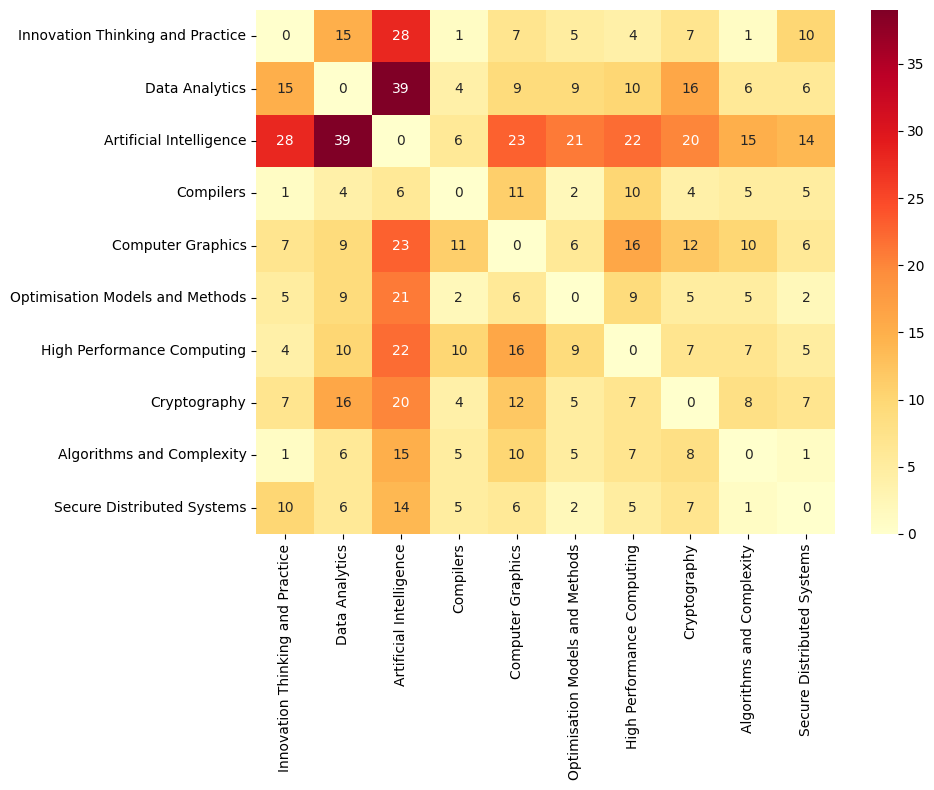

In [10]:

cooccurrence = pd.DataFrame(0, index=all_modules, columns=all_modules)

for idx, row in df.iterrows():
    choices = [row['first_choice'], row['second_choice'], row['third_choice']]

    for mod1, mod2 in combinations(choices, 2):
        cooccurrence.loc[mod1, mod2] += 1
        cooccurrence.loc[mod2, mod1] += 1 
        

plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence , annot=True, fmt='d', cmap='YlOrRd')
# plt.title(f'Co-occurrence Matrix (Given {i} is chosen)')
plt.tight_layout()
plt.show()
